# ESTRUCTURAL PREPROCESSING

In [13]:
#Imports

import pandas as pd
from pathlib import Path
import jmespath
import json
from PIL import Image
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt



## ETL for metadata

Each json has this format "PetID"-"nFoto".json

In [3]:
metada_path = Path("../data/data_metadata")

In [4]:
def imageBrightness(content):
    colors = jmespath.search ("imagePropertiesAnnotation.dominantColors.colors || `[]`", content)
    
    total_brightness = 0
    
    for c in colors:
        r = c['color'].get('red', 0)
        g = c['color'].get('green', 0)
        b = c['color'].get('blue', 0)
        score = c.get('score', 0)
        
        # Brightness formula
        brightness = (0.299 * r) + (0.587 * g) + (0.114 * b)
        
        #Score
        total_brightness += brightness * score
        
    return total_brightness

In [ ]:
def calculate_focus_ratio(image_file, content):
    vertices = jmespath.search("cropHintsAnnotation.cropHints[0].boundingPoly.vertices", content)

    if not vertices: #early exit
        return 0.0
    
    x_coords = [v.get('x', 0) for v in vertices]
    y_coords = [v.get('y', 0) for v in vertices]

    width = max(x_coords) - min(x_coords)
    height = max(y_coords) - min(y_coords)
    area = width * height
    try:
        with Image.open(image_file) as img:
                wid, hgt = img.size
    except Exception as e:
        print(f"Error opening the image {image_file}: {e}")
        return 0.0 

    if wid == 0 or hgt == 0:
        return 0.0
            
    
    focus_ratio = area / (wid * hgt)

    return focus_ratio
    




In [16]:
metadata_df = []

for json_file in metada_path.rglob("*.json"):
    try: 
        with open(json_file, "r") as file: 

            content = json.load(file)

            #we get the pet image
            image_file = "../data/train_images/"+json_file.stem+".jpg"
            subject_focus_ration = calculate_focus_ratio(image_file, content)
            register = {
                "PetId": json_file.stem.split("-")[0],
                "Subject_Focus_Ratio":subject_focus_ration,
                "Crop_Confidence": jmespath.search("cropHintsAnnotation.cropHints[0].confidence", content),
                "Image_Brightness": imageBrightness(content),
                "Visual_Puppy_Score": jmespath.search("labelAnnotations[?contains(description, 'puppy')].score | [0]", content)
            }
            metadata_df.append(register)

            #to ensure it works
            #print(f"Id: {json_file.stem.split("-")[0]} ..... Confidence: {cropHints_score}") 
    except Exception as e: 
        print(e)


In [ ]:
metadata_df = pd.DataFrame(metadata_df)
#we store it
metadata_df.to_parquet("intermediate_data/raw_parquets/metadata_df.parquet", index=False)



In [36]:
#we read it
met_df= pd.read_parquet("intermediate_data/raw_parquets/metadata_df.parquet")
print(met_df)

           PetId  Subject_Focus_Ratio  Crop_Confidence  Image_Brightness  \
0      0008c5398             0.995053              0.8        103.394380   
1      0008c5398             0.995145              0.8        108.881435   
2      0008c5398             0.994506              0.8         91.037458   
3      0008c5398             0.994483              0.8         87.901907   
4      0008c5398             0.994137              0.8        114.453623   
...          ...                  ...              ...               ...   
58306  fffa39a6a             0.993103              0.8         89.175410   
58307  fffa39a6a             0.994221              0.8         82.530806   
58308  fffd78a11             0.993750              0.8        182.066446   
58309  fffd78a11             0.993067              0.8        152.933467   
58310  fffd9b5a8             0.994175              0.8        137.560632   

       Visual_Puppy_Score  
0                     NaN  
1                     NaN  
2  

## ETL for sentiment

In [22]:
sentiment_path = Path("../data/data_sentiment")

In [25]:
sentiment_info = []


for json_file in sentiment_path.rglob("*.json"):
    try: 
        with open(json_file, "r") as file: 

            content = json.load(file)

            text = jmespath.search("to_string(entities)", content)

            has_whats = 0
            has_call = 0
            if "whatsap" in text.lower(): #whatsap without last p so that errors are also taken into account
                has_whats = 1
            if "call" in text.lower():
                has_call = 1
            register = {
                "PetId":json_file.stem,
                "NLP_Sentiment_Score":jmespath.search("documentSentiment.score || `0.0`", content) ,
                "NLP_Emotional_Intensity":jmespath.search("documentSentiment.magnitude || `0.0`", content),
                "WhatsApp": has_whats,
                "Call": has_call
            }
            sentiment_info.append(register)

    except Exception as e: 
        print(e)


In [ ]:
sentiment_df = pd.DataFrame(sentiment_info)
#we store it
sentiment_df.to_parquet("intermediate_data/raw_parquets/sentiment_df.parquet", index=False)



In [37]:
#we read it
sent_df= pd.read_parquet("intermediate_data/raw_parquets/sentiment_df.parquet")
print(sent_df)

           PetId  NLP_Sentiment_Score  NLP_Emotional_Intensity  WhatsApp  Call
0      0008c5398                  0.7                      2.8         0     0
1      000a290e4                  0.3                      0.6         1     1
2      000fb9572                  0.3                      0.8         0     0
3      0011d7c25                  0.8                      0.8         0     0
4      00156db4a                  0.0                      1.8         0     0
...          ...                  ...                      ...       ...   ...
14437  fff24fcb5                  0.3                      1.2         0     0
14438  fff4a6420                  0.9                      3.7         0     0
14439  fff6f2f61                  0.5                      3.3         0     0
14440  fffd78a11                  0.8                      1.6         0     0
14441  fffd9b5a8                  0.9                      0.9         0     0

[14442 rows x 5 columns]


## Clean and validate metadata df

In metadata we have to aggregate information by PetId since each pet can have more than 1 photo

14652
(58311, 5)
14652
(14652, 5)


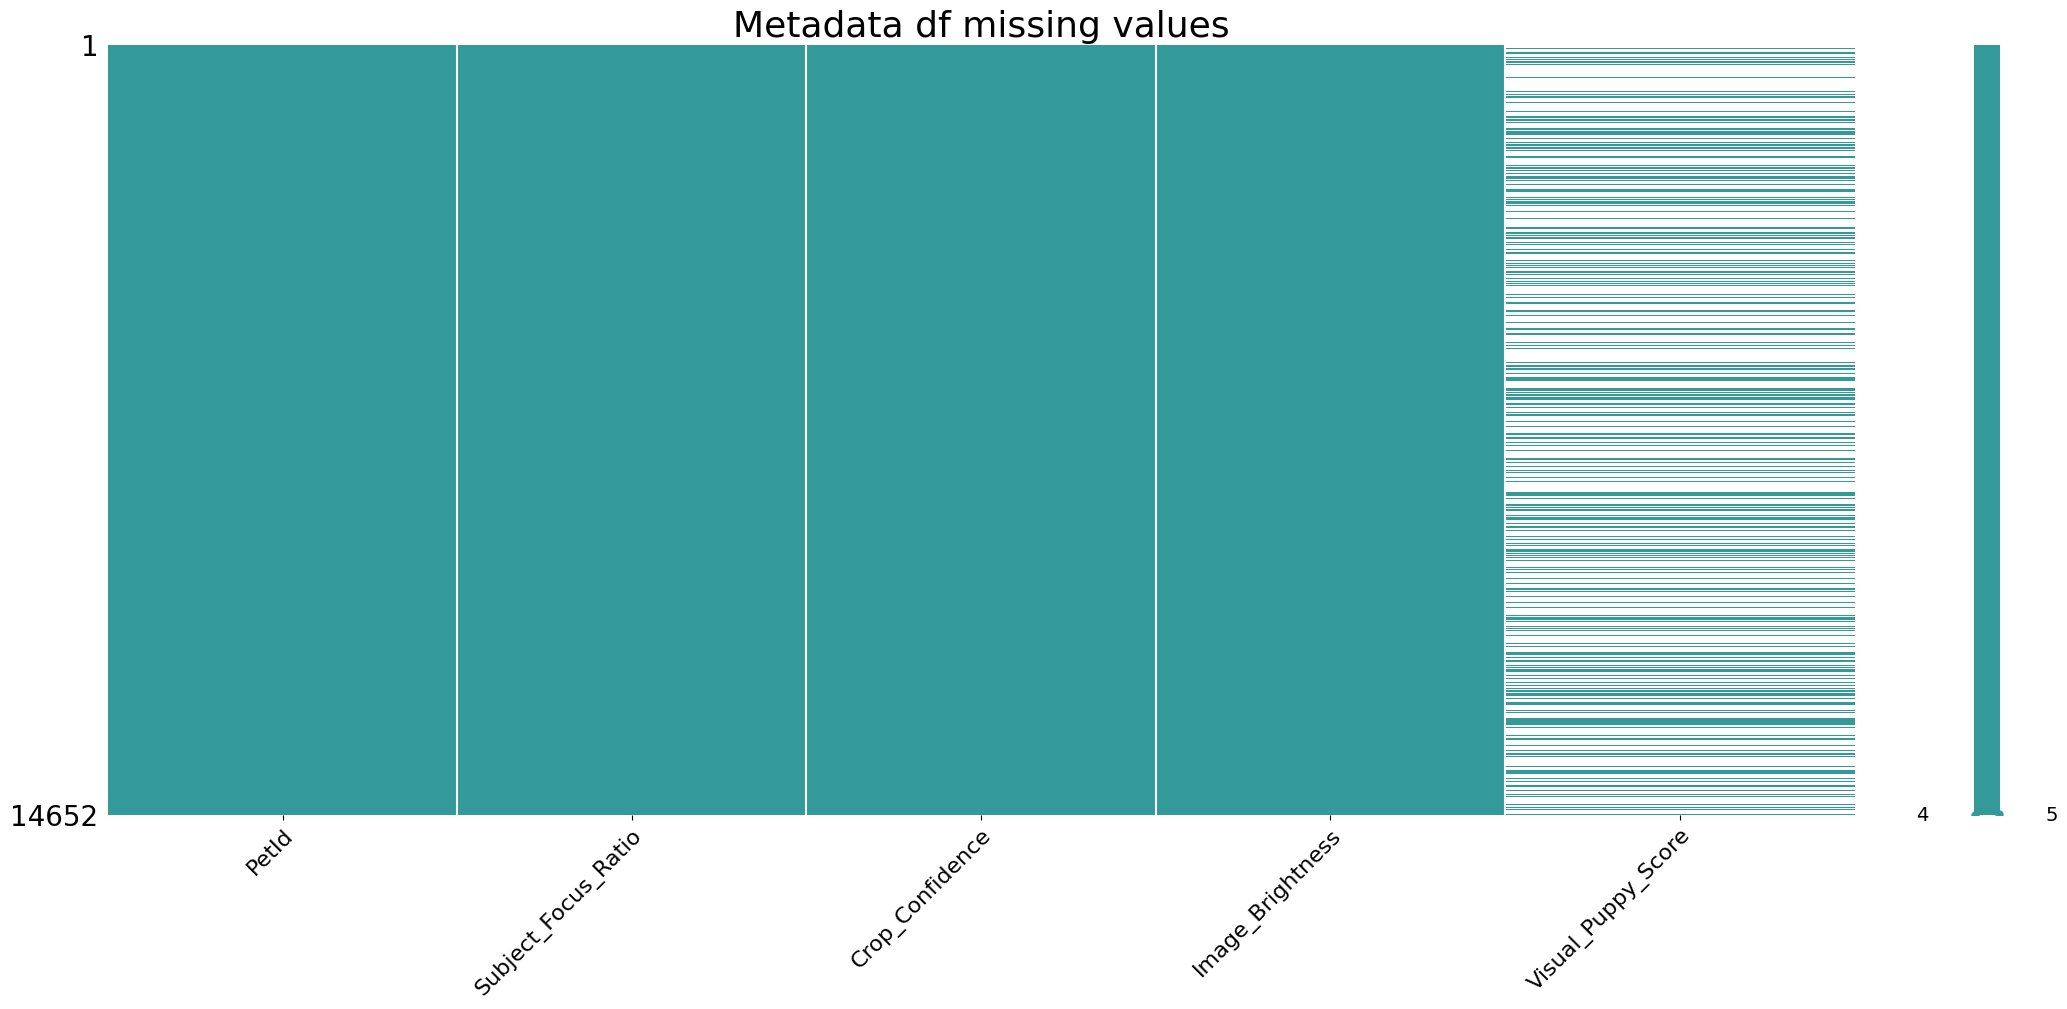


Null values per columns
PetId                     0
Subject_Focus_Ratio       0
Crop_Confidence           0
Image_Brightness          0
Visual_Puppy_Score     9899
dtype: int64

Null values per columns
PetId                  0
Subject_Focus_Ratio    0
Crop_Confidence        0
Image_Brightness       0
Visual_Puppy_Score     0
dtype: int64
['PetID', 'Subject_Focus_Ratio', 'Crop_Confidence', 'Image_Brightness', 'Visual_Puppy_Score']


In [38]:
#1. Group data by PetId

#PetId: 14652 unique values 
print(len(met_df["PetId"].unique()))
#Rows: 58311 
print(met_df.shape)

#We will group by PetId
grouped_met_df = met_df.groupby("PetId").agg({"Subject_Focus_Ratio":"mean","Crop_Confidence":"mean", "Image_Brightness":"mean","Visual_Puppy_Score":"max"}).reset_index()

#PetId: 14652 unique values 
print(len(grouped_met_df["PetId"].unique()))
#Rows: 14652 rows
print(grouped_met_df.shape)
#print(grouped_met_df)


#2. Handle missing values

#Missing values visualization
ax = msno.matrix(grouped_met_df, color=(0.2, 0.6, 0.6))
ax.xaxis.set_ticks_position('bottom')
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.title("Metadata df missing values", fontsize=26)
plt.savefig('../images/missing_values_metadata.png', bbox_inches='tight') 
plt.show()



print (f"\nNull values per columns\n{grouped_met_df.isnull().sum()}")
#When Puppy Score is Null it means that the Google Vision Api did not detect a Puppy, we will set the value to 0ç
grouped_met_df["Visual_Puppy_Score"] = grouped_met_df["Visual_Puppy_Score"].fillna(0)

print (f"\nNull values per columns\n{grouped_met_df.isnull().sum()}")


#3. In the original Data the pet id column is: PetID, but in this df it is PetId, we will change it

grouped_met_df.rename(columns={"PetId":"PetID"}, inplace=True)
print(grouped_met_df.columns.tolist())

#we store it
grouped_met_df.to_parquet("intermediate_data/cleaned_parquets/metadata_cleaned_df.parquet", index=False)



In [3]:
#we read it
cleaned_met_df= pd.read_parquet("intermediate_data/cleaned_parquets/metadata_cleaned_df.parquet")
print(cleaned_met_df)

           PetID  Subject_Focus_Ratio  Crop_Confidence  Image_Brightness  \
0      0008c5398             0.994745              0.8        102.793564   
1      000a290e4             0.995145              0.8         77.381149   
2      000fb9572             0.994043              0.8         78.090047   
3      0011d7c25             0.994168              0.8        132.630830   
4      00156db4a             0.993764              0.8        128.680281   
...          ...                  ...              ...               ...   
14647  fff4a6420             0.995478              0.8         92.784493   
14648  fff6f2f61             0.995145              0.8         60.569381   
14649  fffa39a6a             0.993662              0.8         85.853108   
14650  fffd78a11             0.993408              0.8        167.499957   
14651  fffd9b5a8             0.994175              0.8        137.560632   

       Visual_Puppy_Score  
0                0.000000  
1                0.601741  
2  

## Clean and validate sentiments df

Kaggle: There are some descriptions that the API could not analyze. As such, there are fewer sentiment files than there are rows in the dataset.

14442
(14442, 5)


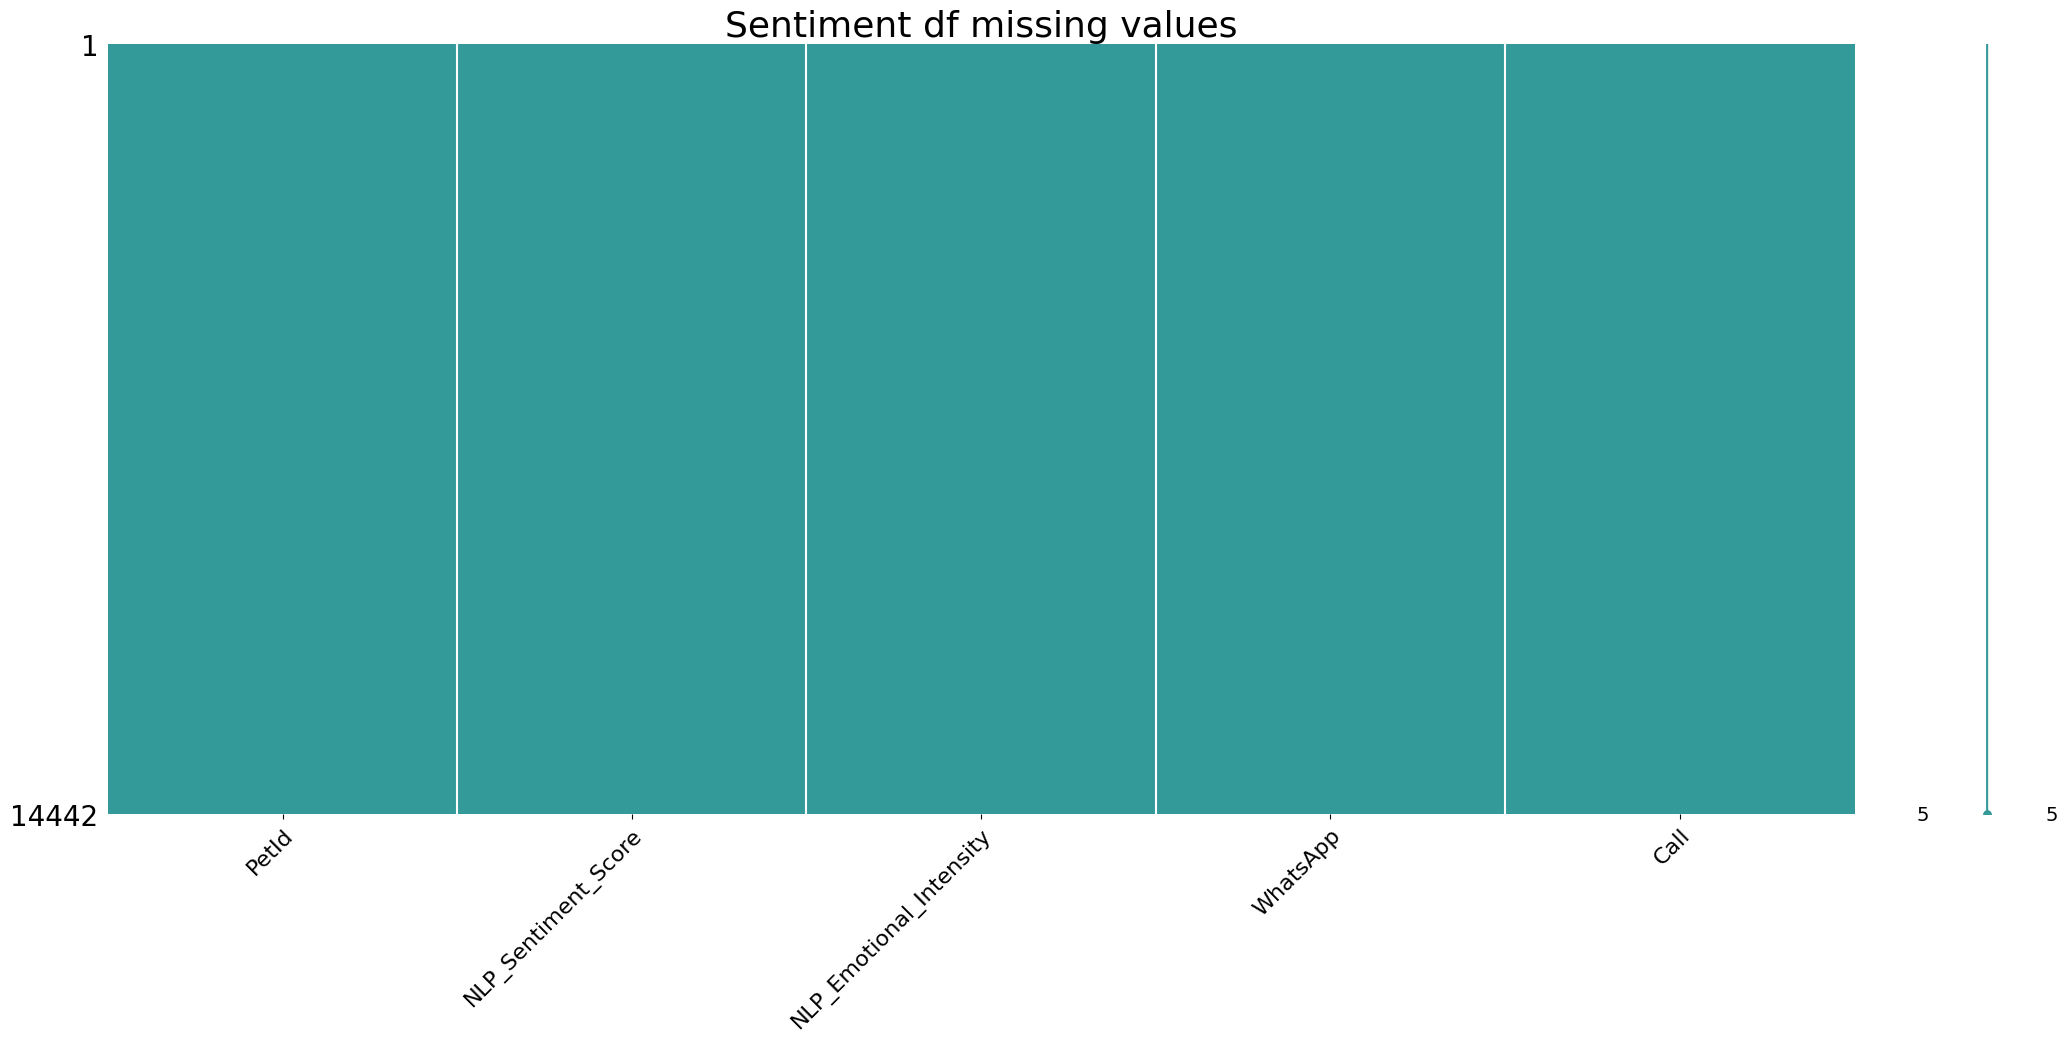

Missing values per columns:
 PetId                      0
NLP_Sentiment_Score        0
NLP_Emotional_Intensity    0
WhatsApp                   0
Call                       0
dtype: int64
['PetID', 'NLP_Sentiment_Score', 'NLP_Emotional_Intensity', 'WhatsApp', 'Call']


In [39]:

#PetId: 14442 unique values 
print(len(sent_df["PetId"].unique()))
#Rows: 14442 
print(sent_df.shape)



#1.We will check for missing values 

#Missing values visualization
ax = msno.matrix(sent_df, color=(0.2, 0.6, 0.6))
ax.xaxis.set_ticks_position('bottom')
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.title("Sentiment df missing values", fontsize=26)
plt.savefig('../images/missing_values_sentiments.png', bbox_inches='tight') 
plt.show()


print(f"Missing values per columns:\n {sent_df.isnull().sum()}") #No missing values

#2. In the original Data the pet id column is: PetID, but in this df it is PetId, we will change it

sent_df.rename(columns={"PetId":"PetID"}, inplace=True)
print(sent_df.columns.tolist())

#we store it
sent_df.to_parquet("intermediate_data/cleaned_parquets/sentiment_cleaned_df.parquet", index=False)




In [32]:
#we read it
cleaned_sent_df= pd.read_parquet("intermediate_data/cleaned_parquets/sentiment_cleaned_df.parquet")
print(cleaned_sent_df)

           PetID  NLP_Sentiment_Score  NLP_Emotional_Intensity  WhatsApp  Call
0      0008c5398                  0.7                      2.8         0     0
1      000a290e4                  0.3                      0.6         1     1
2      000fb9572                  0.3                      0.8         0     0
3      0011d7c25                  0.8                      0.8         0     0
4      00156db4a                  0.0                      1.8         0     0
...          ...                  ...                      ...       ...   ...
14437  fff24fcb5                  0.3                      1.2         0     0
14438  fff4a6420                  0.9                      3.7         0     0
14439  fff6f2f61                  0.5                      3.3         0     0
14440  fffd78a11                  0.8                      1.6         0     0
14441  fffd9b5a8                  0.9                      0.9         0     0

[14442 rows x 5 columns]


## Join original data with metadata and sentimens


In [33]:
DATA_PATH = "../data/data.csv"
data_train = pd.read_csv(DATA_PATH)


#print(data_train.head(5))
print(data_train.shape)


(14993, 24)


In [34]:

#Join data_train, cleaned metadata and cleaned sentiment by PetId

df_final = data_train.merge(cleaned_met_df, on="PetID", how="left") \
                  .merge(cleaned_sent_df, on="PetID", how="left")


print(df_final.shape)

#we store it
df_final.to_parquet("intermediate_data/raw_final_df/df_final.parquet", index=False)


(14993, 32)


In [35]:
#we read it
df_final= pd.read_parquet("intermediate_data/raw_final_df/df_final.parquet")
print(df_final)

       Type            Name  Age  Breed1  Breed2  Gender  Color1  Color2  \
0         2          Nibble    3     299       0       1       1       7   
1         2     No Name Yet    1     265       0       1       1       2   
2         1          Brisco    1     307       0       1       2       7   
3         1            Miko    4     307       0       2       1       2   
4         1          Hunter    1     307       0       1       1       0   
...     ...             ...  ...     ...     ...     ...     ...     ...   
14988     2            None    2     266       0       3       1       0   
14989     2  Serato & Eddie   60     265     264       3       1       4   
14990     2         Monkies    2     265     266       3       5       6   
14991     2         Ms Daym    9     266       0       2       4       7   
14992     1            Fili    1     307     307       1       2       0   

       Color3  MaturitySize  ...  PhotoAmt  AdoptionSpeed  \
0           0             

In [ ]:
#Check for missing values



#Missing values visualization
ax = msno.matrix(df_final, color=(0.2, 0.6, 0.6))
ax.xaxis.set_ticks_position('bottom')
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.title("Final df missing values", fontsize=26)
plt.savefig('../images/missing_values_final.png', bbox_inches='tight') 
plt.show()



print(f"Missing Values per column:\n{df_final.isna().sum()}")

#Missing value imputation
df_final["Subject_Focus_Ratio"] = df_final["Subject_Focus_Ratio"].fillna(-1)
df_final["Crop_Confidence"] = df_final["Crop_Confidence"].fillna(-1)
df_final["Image_Brightness"] = df_final["Image_Brightness"].fillna(-1)
df_final["Visual_Puppy_Score"] = df_final["Visual_Puppy_Score"].fillna(-1)

df_final["NLP_Sentiment_Score"] = df_final["NLP_Sentiment_Score"].fillna(-99)
df_final["NLP_Emotional_Intensity"] = df_final["NLP_Emotional_Intensity"].fillna(-1)
df_final["WhatsApp"] = df_final["WhatsApp"].fillna(0)
df_final["Call"] = df_final["Call"].fillna(0)

df_final["Name"] = df_final["Name"].fillna("")
df_final["Name"] = np.where (df_final["Name"] == "No Name", "",df_final["Name"] )

df_final["Description"] = df_final["Description"].fillna("")

#Ensure that missing values imputation was correct
print(f"Missing Values per column:\n{df_final.isna().sum()}")

#We create a binary column has_sentiment_data representing if the API was able to get the sentiments data from the description (yes was able, no was not able) = (0,1)
df_final["has_sentiment_data"] = np.where(df_final["NLP_Sentiment_Score"]==-99, 0,1 )

#We create a binary column has_name (yes has name, no has not name) = (0,1)
df_final["has_name"] = np.where(df_final["Name"]=="", 0,1 )

#We create a binary column has_description (yes has description, no has not description) = (0,1)
df_final["has_description"] = np.where(df_final["Description"]=="", 0,1 )

#We create a column of the length of the Name 
df_final["Name_length"] = df_final["Name"].str.len()


#We will delete columns that do not give any information: Description, Name, PetID
df_final.drop(["Description", "Name", "PetID"], axis=1, inplace=True)
print(df_final.columns.tolist())


#We convert the categorical variable to string so that the preprocessor works properly


categorical_columns = ['Breed1', 'Breed2', 'State',"RescuerID",'Type', 'Gender', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength']
df_final[categorical_columns] = df_final[categorical_columns].astype(str)


Missing Values per column:
Type                          0
Name                       1265
Age                           0
Breed1                        0
Breed2                        0
Gender                        0
Color1                        0
Color2                        0
Color3                        0
MaturitySize                  0
FurLength                     0
Vaccinated                    0
Dewormed                      0
Sterilized                    0
Health                        0
Quantity                      0
Fee                           0
State                         0
RescuerID                     0
VideoAmt                      0
Description                  13
PetID                         0
PhotoAmt                      0
AdoptionSpeed                 0
Subject_Focus_Ratio         341
Crop_Confidence             341
Image_Brightness            341
Visual_Puppy_Score          341
NLP_Sentiment_Score         551
NLP_Emotional_Intensity     551
WhatsApp     

In [ ]:

#We store the cleaned final df
df_final.to_parquet("../data/cleaned/cleaned_df_final.parquet", index=False)



NameError: name 'df_final' is not defined

In [ ]:
#we read it
df_final= pd.read_parquet("../data/cleaned/cleaned_df_final.parquet")
print(df_final)


       Type  Age Breed1 Breed2  Gender  Color1  Color2  Color3  MaturitySize  \
0         2    3    299      0       1       1       7       0             1   
1         2    1    265      0       1       1       2       0             2   
2         1    1    307      0       1       2       7       0             2   
3         1    4    307      0       2       1       2       0             2   
4         1    1    307      0       1       1       0       0             2   
...     ...  ...    ...    ...     ...     ...     ...     ...           ...   
14988     2    2    266      0       3       1       0       0             2   
14989     2   60    265    264       3       1       4       7             2   
14990     2    2    265    266       3       5       6       7             3   
14991     2    9    266      0       2       4       7       0             1   
14992     1    1    307    307       1       2       0       0             2   

       FurLength  ...  Image_Brightness

# Statistical Preprocessing (preprocessor.py)

Preprocessing that can cause data leakage if it is not done correctly. 

